## ISSUE 2: 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import get_HEP_data as gHd

### Task 1 (n_hits vs eta)
$$
\eta = -\ln \left[ \tan \left(\frac{\theta}{2}\right) \right] =\frac{1}{2} \ln \left[ \frac{|\vec{p}| + p_z}{|\vec{p}| - p_z} \right]
$$

/var/folders/vw/5snrydv96d34jy4vgx0h68t80000gn/T/ipykernel_81919/2574241736.py:29: RuntimeWarning: invalid value encountered in divide
  H_norm = H / H.sum(axis=1, keepdims=True)


Text(-1, 7.5, '9 hits')

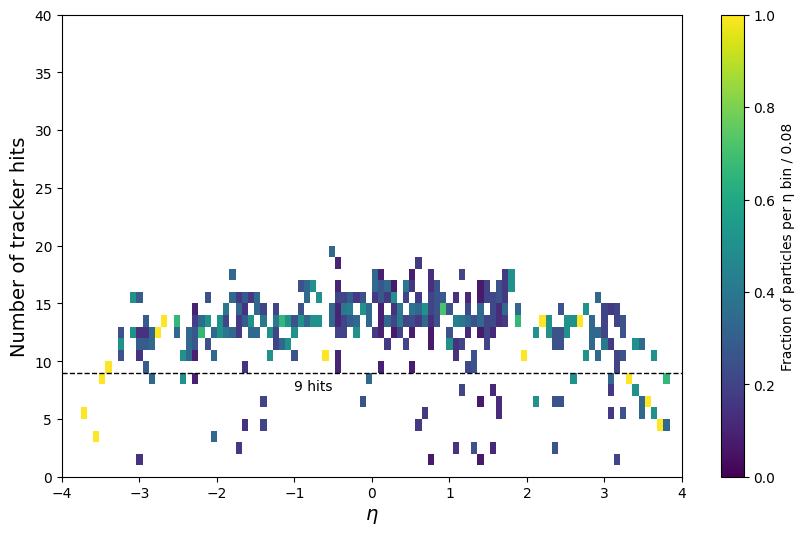

In [54]:
particles = gHd.get_particles()

particles = particles[abs(particles['vx']) < 1]
particles = particles[abs(particles['vy']) < 1]
particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
particles = particles[particles['pT'] > 1]

particles = particles[particles['charge'] != 0]

particles['p'] = np.sqrt(particles['px']**2 + particles['py']**2 + particles['pz']**2)

particles['eta'] = 1/2 * np.log(
    (particles['p'] + particles['pz'])/
    (particles['p'] - particles['pz'])
)

particles = particles[particles['num_tracker_hits'] > 0]

eta_bins = np.linspace(-4, 4, 101)
hits_bins = np.arange(0, 41, 1)

# Compute 2D histogram 
H, xedges, yedges = np.histogram2d(
    particles['eta'], 
    particles['num_tracker_hits'], 
    bins=(eta_bins, hits_bins)
)

H_norm = H / H.sum(axis=1, keepdims=True)
H_norm = np.nan_to_num(H_norm)  # replace NaNs from empty bins with 0

H_masked = np.ma.masked_where(H_norm == 0, H_norm) 

cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')

fig, ax = plt.subplots(figsize=(10, 6))
pcm = ax.pcolormesh(
    xedges, yedges, H_masked.T,
    cmap=cmap,
    vmin=0, vmax=np.max(H_norm)  # linear color scale
)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label('Fraction of particles per η bin / {:.2f}'.format(xedges[1]-xedges[0]))

# Axis labels and style
ax.set_xlabel(r'$\eta$', fontsize=14)
ax.set_ylabel('Number of tracker hits', fontsize=14)
ax.set_xlim(-4, 4)
ax.set_ylim(0, 40)

# Dashed reference line at 9 hits 
ax.axhline(9, color='k', linestyle='--', linewidth=1)
ax.text(-1, 7.5, '9 hits', fontsize=10, color='k')


### Task 2 (Calo Hits Distribution)

(0.0, 1600.0)

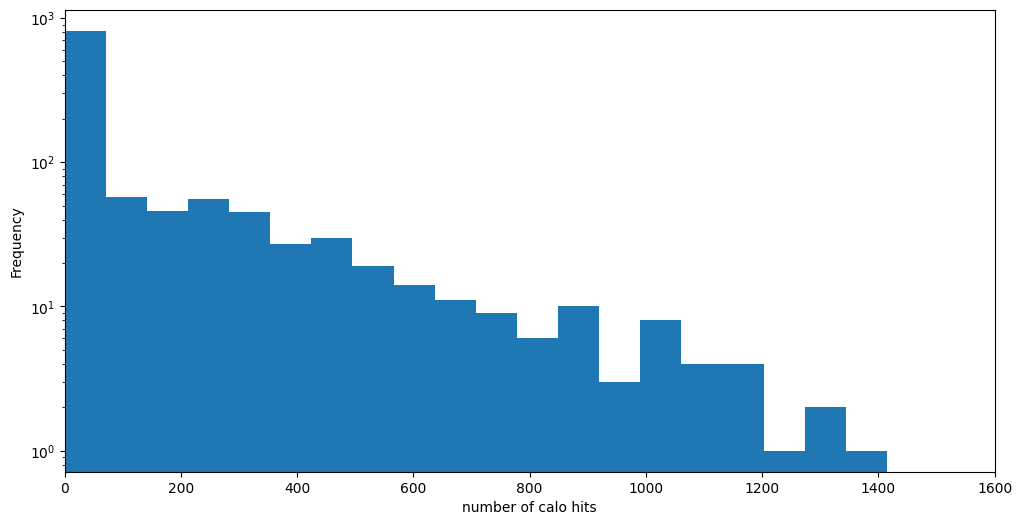

In [68]:
fig, ax = plt.subplots(figsize=(12,6))

particles = gHd.get_particles()
particles = particles[abs(particles['vx']) < 1]
particles = particles[abs(particles['vy']) < 1]
particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
particles = particles[particles['pT'] > 1]

particles = particles[particles['num_calo_hits'] < 1500]

ax.hist(particles['num_calo_hits'], bins=20)

ax.set_yscale('log')

ax.set_ylabel('Frequency')

ax.set_xlabel('number of calo hits')

ax.set_xlim(0,1600)

In [69]:
import json

all_events_data = {}

for n in range(10):
    # retreaving data:
    particles = gHd.get_particles()
    tracker_hits = gHd.get_tracker_hits()
    particles = particles[particles['event_id'] == n].copy()
    tracker_hits = tracker_hits[tracker_hits['event_id'] == n].copy()

    # Setting conditions
    particles = particles[abs(particles['vx']) < 1]
    particles = particles[abs(particles['vy']) < 1]
    particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
    particles = particles[particles['pT'] > 1]

    # Getting tracker hits that match the particles
    particles_id = particles["particle_id"].unique()
    tracker_hits = tracker_hits[tracker_hits["particle_id"].isin(particles_id)]
        
    # Finding the radius from the center of detector:
    # Note: Using x,y,z from the *origin* (0,0,0).
    tracker_hits['r'] = np.sqrt(tracker_hits['x']**2 + tracker_hits['y']**2)
    # Ordering data with respect to the radius so that straight lines are plotted
    tracker_hits = tracker_hits.sort_values(by=['particle_id', 'r'])

    event_tracks = []
    # Group by particle_id to create individual tracks
    for particle_id, group_of_hits in tracker_hits.groupby('particle_id'):
        # Get the points as a list of dictionaries: [{'x':_,'y':_,'z':_}, ...]
        points = group_of_hits[['x', 'y', 'z']].to_dict(orient='records')
        
        # We need at least 2 points to draw a line
        if len(points) > 1:
            event_tracks.append({
                'particle_id': int(particle_id),
                'points': points
            })
    
    all_events_data[n] = event_tracks
    print(f"Event {n}: Processed {len(event_tracks)} tracks.")

# Save all processed event data to a JSON file
output_filename = 'data/tracks_data.json'
with open(output_filename, 'w') as f:
    json.dump(all_events_data, f, indent=4)

Event 0: Processed 17 tracks.
Event 1: Processed 28 tracks.
Event 2: Processed 30 tracks.
Event 3: Processed 40 tracks.
Event 4: Processed 25 tracks.
Event 5: Processed 55 tracks.
Event 6: Processed 52 tracks.
Event 7: Processed 45 tracks.
Event 8: Processed 48 tracks.
Event 9: Processed 60 tracks.
